# Heart Disease Diagnosis Model

## Part 1: Exploratory Data Analysis

Here's an example notebook file for performing exploratory data analysis (EDA) on an open medical dataset. 

We will use the Heart Disease UCI dataset (a commonly used medical dataset) available from UCI Machine Learning Repository and Kaggle. Dataset was downloaded from Kaggle: https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data

**Dataset description**

The Heart Disease dataset dates from 1988 and consists of four databases: Cleveland, Hungary, Switzerland, and Long Beach V. It contains 76 columns, including the predicted (target) column, but all published experiments refer to using a subset of 15 of them. The "target" column refers to the presence of heart disease in the patient.

The dataset obtained from Kaggle is composed of 15 features (also known as independent variables, input variables) which are age, sex, location of study, chest pain type, resting blood pressure, serum cholesterol, fasting blood sugar, resting electrocardiographic results, maximum heart rate achieved, exercise-induced angina, oldpeak — ST depression induced by exercise relative to rest, the slope of the peak exercise ST segment, number of major vessels and Thalassemia. The last (16th) column, called num, represents the stages of heart disease and serves as the target variable. 

A target variable (also known as the dependent variable, response variable, or output variable) is the variable that you are trying to predict or explain in a dataset during a machine learning (ML) or statistical analysis task respectively. The target variable defines the objective of a ML model. A ML model learns the relationship between the features (independent variables) and the target variable during training. The type of the target variable (categorical, continuous) determines the type of model (e.g., classification vs regression).

Here, the target variable is categorical, since it involves discrete values. Therefore, this is a classification problem. Classification aims to assign data observations (here, patients) to predefined classes, like determining the patient's heart disease stage (0-4). When the number of predefined classes is more than two (in our dataset there are 5 patient classes), we have a multi-class classification problem. On the other hand, when we have only two classes (e.g. 0 or 1), we have a binary classification problem.

**Relevant Papers:**

* Detrano, R., Janosi, A., Steinbrunn, W., Pfisterer, M., Schmid, J., Sandhu, S., Guppy, K., Lee, S., & Froelicher, V. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. American Journal of Cardiology, 64,304--310.
Web Link
* David W. Aha & Dennis Kibler. "Instance-based prediction of heart-disease presence with the Cleveland database." Web Link
* Gennari, J.H., Langley, P, & Fisher, D. (1989). Models of incremental concept formation. Artificial Intelligence, 40, 11--61. Web Link

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load Heart Disease UCI dataset
df = pd.read_csv("heart_disease_uci.csv")
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [3]:
# Overview of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (920, 16)


In [4]:
# Dataset Column names
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [5]:
# print first 5 Rows
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


Column descriptions:

* id: Unique id for each patient (useless column - to be dropped)
* age: Age of the patient in years
* sex: Gender (Male, Female)
* dataset: location of data collection (Cleveland, Hungary, Switzerland, and Long Beach V)
* cp: Chest pain type (typical angina, atypical angina, non-anginal, asymptomatic)
* trestbps: Resting blood pressure (resting blood pressure (in mm Hg on admission to the hospital))
* chol: Serum cholesterol in mg/dl
* fbs: Fasting blood sugar > 120 mg/dl (True/, False)
* restecg: Resting ECG results (normal, stt abnormality, lv hypertrophy)
* thalach: Maximum heart rate achieved
* exang: Exercise-induced angina (True, False)
* oldpeak: ST depression induced by exercise relative to rest
* slope: Slope of the peak exercise ST segment
* ca: Number of major vessels (0-3) colored by fluoroscopy
* thal: Thalassemia (normal; fixed defect; reversible defect)
* num: 0 = no heart disease; 1,2,3,4 = stages of heart disease

### Check if target variable is balanced or unbalanced

In general:

* A dataset is considered balanced if each class of the target variable has roughly equal representation (e.g., 50% for binary classification).
* A dataset is considered unbalanced if one class of the target variable dominates the others, as in this case.

In an unbalanced classification problem, one class (often the majority class) has significantly more samples than the other class (or classes). This imbalance can lead to several issues that affect the performance and reliability of your machine learning model.

**Problems with Unbalanced Classification**

1. Bias Toward the Majority Class
    * Most machine learning algorithms aim to maximize overall accuracy. When one class dominates, the model may simply predict the majority class most of the time to achieve high accuracy, ignoring the minority class.
    * Example: In a dataset with 90% "No Disease" and 10% "Disease," a model that always predicts "No Disease" will have 90% accuracy but completely fail to identify "Disease" cases.
2. Poor Minority Class Performance
    * The model often struggles to correctly predict instances of the minority class (e.g., "Disease") because it doesn't see enough examples of this class during training.
    * This results in poor metrics like recall, precision, or F1-score for the minority class.
3. Misleading Metrics
    * Metrics like accuracy can be misleading in unbalanced datasets:
        - If 95% of the data belongs to one class, a model predicting only that class would achieve 95% accuracy without learning anything meaningful.
    * Other metrics like precision, recall, F1-score, or area under the ROC curve (AUC-ROC) are more appropriate for imbalanced datasets.
4. Generalization Issues
    * The model may overfit the majority class and fail to generalize well to the minority class, especially in real-world data where the minority class is often the most critical.
5. Underrepresentation of Important Insights
     * In real-world problems (e.g., fraud detection, disease diagnosis), the minority class is often more important. Failing to identify minority class instances can have severe consequences.
6. Reduced Model Confidence
    * The model may output lower confidence scores for the minority class predictions due to insufficient training examples, which can reduce trust in the predictions.

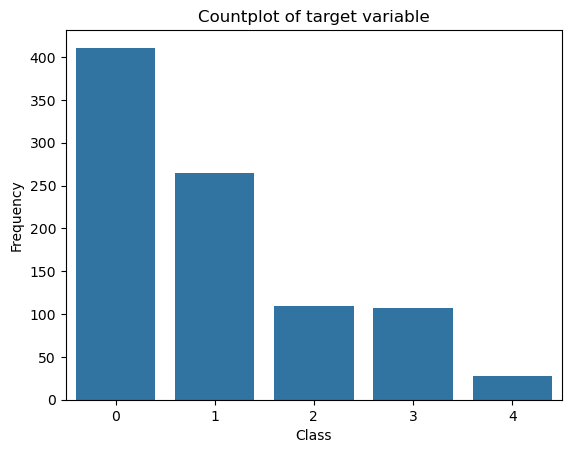

In [6]:
fig, ax = plt.subplots()
sns.countplot(data=df, x='num')
ax.set_title("Countplot of target variable")
ax.set_xlabel("Class")
ax.set_ylabel("Frequency")
plt.show()

The countplot confirms that the dataset is unbalanced, since the number of patients belonging to each class is uneven. For example the majority class (No Disease - 0) has significantly more instances compared to the minority class (Disease stage 4).

**What to Do if the Dataset Is Unbalanced?**

If the actual dataset we're working with is unbalanced, we might consider:

* Oversampling the minority class (e.g., using SMOTE or random oversampling).
* Undersampling the majority class to balance the dataset.
* Using metrics that handle imbalanced data, such F1-score, Precision, Recall instead of just accuracy.

We will come back to this issue later.

### Multi-class to binary classification

We can convert a multi-class classification problem into a binary classification problem by redefining the target classes. For example:

* Combine the classes 1, 2, 3, and 4 into a single "heart disease" class.
* Retain 0 as the "no heart disease" class.

The new binary classification would then look like:

* 0: No heart disease
* 1: Heart disease (combining all levels of severity)

When Should You Convert Multi-Class to Binary?

* Simplification: If your goal is to predict whether or not a patient has heart disease (regardless of severity), binary classification is sufficient.
* Imbalanced Classes: If the multi-class dataset has very imbalanced severity levels (e.g., very few cases for 2, 3, or 4), binary classification may improve performance by reducing the complexity of the task.
* Specific Use Case: If your application requires only a yes/no outcome (e.g., screening for the presence of disease), binary classification is more appropriate.

When Should You Keep It as Multi-Class?

* Understanding Severity: If you want to model the progression or severity of heart disease, keeping it as a multi-class classification problem would retain more information.
* Domain-Specific Applications: For example, doctors may want predictions that differentiate between mild, moderate, and severe disease cases.

In this study, we will use both multi-class and binary classification in EDA for educational purposes.

In [7]:
# Convert target to binary classification
df['num_bin'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

In [8]:
# Check the distribution of the new binary target
print(df['num_bin'].value_counts())

num_bin
1    509
0    411
Name: count, dtype: int64


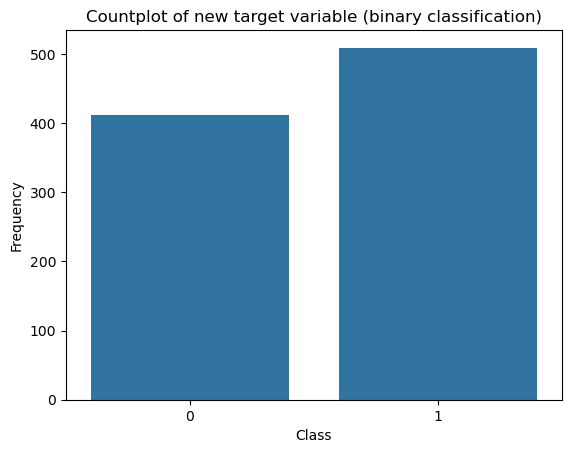

In [9]:
fig, ax = plt.subplots()
sns.countplot(data=df, x='num_bin')
ax.set_title("Countplot of new target variable (binary classification)")
ax.set_xlabel("Class")
ax.set_ylabel("Frequency")
plt.show()

In case we are interested in studying the problem from the perspective of binary classification, we shall use the num_bin column as target variable.

In this case, the dataset seems to be more balanced since two classes (no heart disease -> 0, Heart Disease -> 1) have almost the same number of samples (patients), namely 45% vs 55%.

### Statistical Analysis

In [10]:
# Check for missing values
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
num_bin       0
dtype: int64

Data pre-processing techniques will be used before training Machine Learning (ML) techniques in order to handle missing values.

In [11]:
# Data types
df.dtypes

id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
num_bin       int64
dtype: object

Categorical string-based columns will be encoded to numerical before training ML techniques.

In [12]:
# Basic Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
 16  num_bin   920 non-null    int64  
dtypes: float64(5), int64(4), object(8)
memory usage: 122.3+ KB


In [13]:
# Statistical summary (numerical columns will be presented by default)
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num,num_bin
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652,0.553261
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693,0.497426
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000,1.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000,1.000000


In [14]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")


Number of duplicate rows: 0


In [15]:
# Check if we have equal number of patients from each location
df['dataset'].value_counts()

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

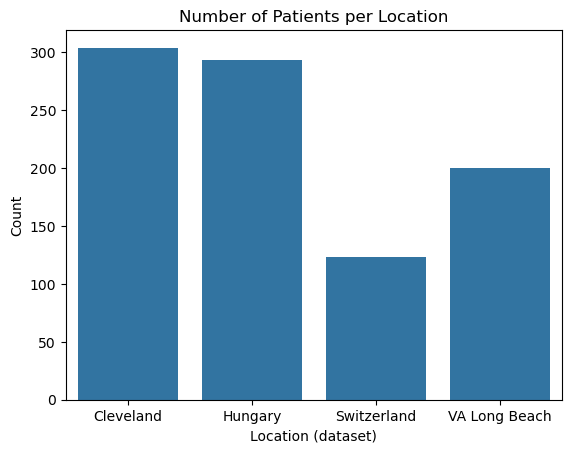

In [16]:
fig, ax = plt.subplots()
sns.countplot(data=df, x="dataset")
ax.set_title("Number of Patients per Location")
ax.set_xlabel("Location (dataset)")
ax.set_ylabel("Count")
plt.show()

**Using binning and grouping**

Binning and grouping the age column in a dataset like the Heart Disease dataset can provide several insights and advantages over using the raw numerical values. Here's what this approach can reveal:

1. Simplifies Patterns and Highlights Trends
    * Raw age values often span a wide range and may not immediately show clear trends. By binning (e.g., grouping ages into ranges like 20–29, 30–39), you can condense the data into categories, making patterns (e.g., disease prevalence increasing with age) more apparent.
2. Facilitates Comparisons Across Groups
    * Grouping allows you to compare how different age categories relate to the target variable (e.g., disease presence). This can be visualized easily using bar plots or count plots.
3. Improves Visualizations
    * Using bins for age can reduce clutter in visualizations. For instance, a count plot of every possible age (e.g., 29, 30, 31, etc.) might be too detailed and overwhelming. Grouping into bins provides a cleaner, more interpretable graph.
4. Focuses on General Trends Instead of Individual Variability
    * Individual age values might have outliers or random noise that obscure overall trends. Binning smooths out these fluctuations and focuses on general trends for each age group.
5. Enables Aggregated Statistical Analysis
    * Grouping by bins allows you to calculate aggregated statistics (mean, median, count, etc.) for each age group, which can provide additional insights.
6. Supports Decision-Making and Interventions
    * When binned, the age column can help identify age groups that might need targeted interventions or medical attention.

In [17]:
# Binning - Group age into bins
bins = [20, 30, 40, 50, 60, 70, 80]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
df['age_bin'] = pd.cut(df['age'], bins=bins, labels=labels)

### Visualizations

#### Distribution of all numerical features
**Purpose**: Understand data characteristics, choose the right prep-processing steps, improve feature engineering and enchance model performance.

1. Understand Data Characteristics
    * Helps identify if features follow a normal distribution, skewed distribution, or have outliers.
    * Knowing the distribution guides decisions on transformations (e.g., log / box-cox / yeo-johnson transformation for skewed data).
2. Choose the Right Preprocessing Steps
    * Scaling: If features have different ranges, standardization (z-score) or normalization (min-max scaling) may be needed.
    * Encoding: If a numerical feature has very few unique values, it might be more appropriate to treat it as categorical.
3. Improve Feature Engineering
    * Some distributions may indicate the need for feature transformations (e.g., binning continuous data into categories).
4. Enhancing Model Performance
    * Understanding feature distributions allows for better handling of skewed or imbalanced data, improving model accuracy.
    * Some ML models (e.g., linear regression, logistic regression) assume normally distributed features—checking distributions helps in deciding whether to apply transformations.

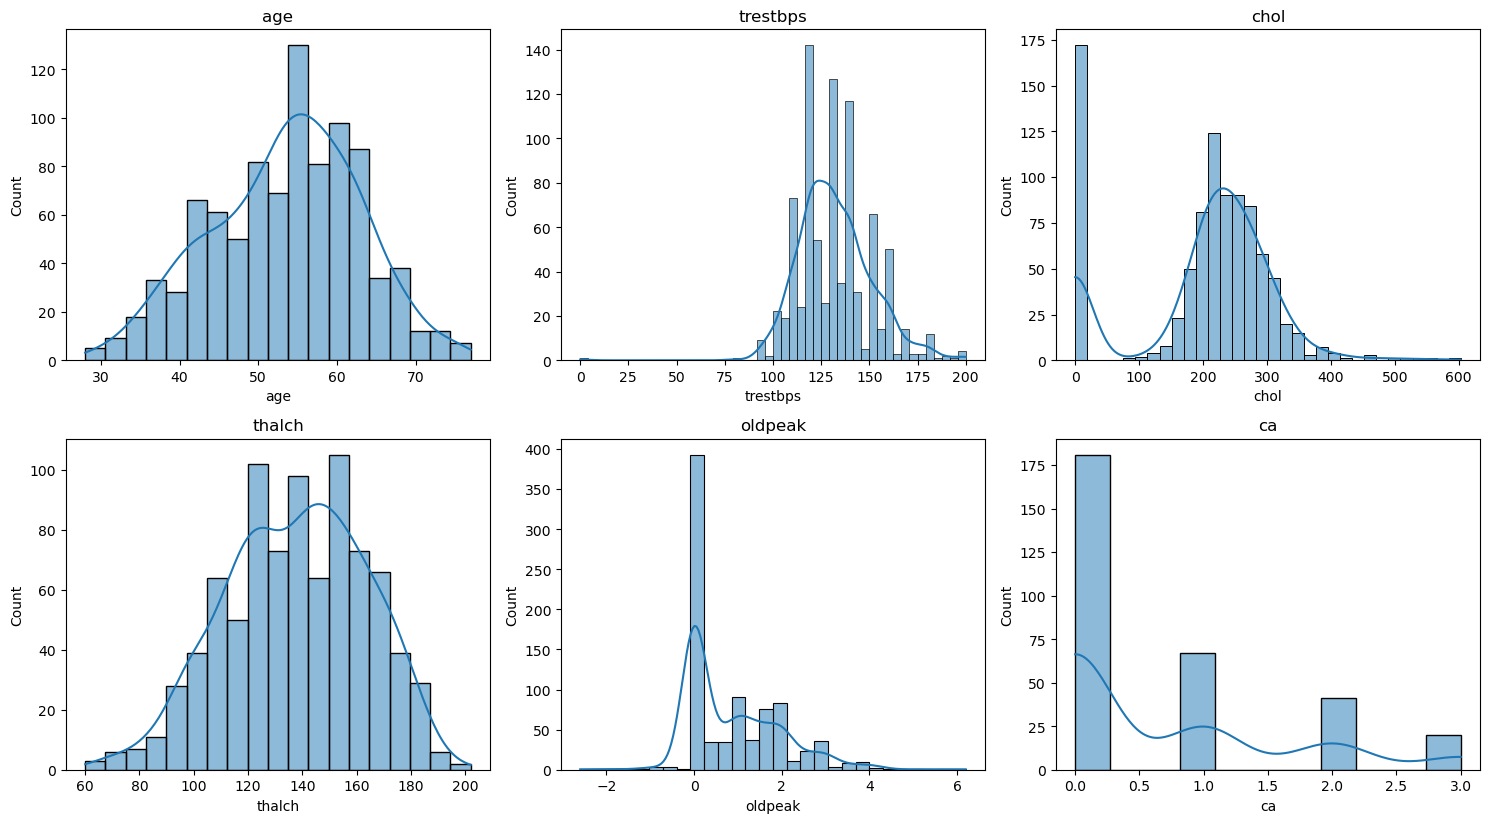

In [18]:
num_features = df.select_dtypes(include=["int64", "float64"]).columns
num_features = num_features.drop(["id", "num", "num_bin"]) # remove the id and the target variable(s) from the set
# Set figure size
plt.figure(figsize=(15, 12))

# Loop through all numerical columns and create subplots
for i, col in enumerate(num_features, 1):
    plt.subplot(len(num_features) // 3 + 1, 3, i)  # Adjust layout dynamically
    sns.histplot(df[col], kde=True)  # Histogram with density plot
    plt.title(col)

plt.tight_layout()
plt.show()

Here are some observations based on the distribution plots:

1. **age & thalach (Max Heart Rate Achieved) & chol (Cholesterol Level)**
    * All seem to follow a roughly normal distribution (bell-shaped) given that the significant number of zero values in the chol graph represent missing values that will be handled during pre-processing.
    * Thalach has a slight right skew, meaning more patients have lower heart rates.
    * There might be outliers in the high range of cholesterol.
2. **trestbps (Resting Blood Pressure)**
    * This appears right-skewed, meaning most values are concentrated on the left but extend far to the right. 
3. **oldpeak (ST Depression Induced by Exercise)**
    * Strong right skew, with a significant number of zero values, possibly indicating many patients had no ST depression.
    * A transformation (e.g., log transformation) might help normalize it.
4. **ca (Number of Major Vessels Colored by Fluoroscopy)**
    * Discrete variable with only a few distinct values (0, 1, 2, 3).
    * The distribution is heavily imbalanced, with most patients having a value of 0.

**Next Steps:** During pre-procesing we can:
* Consider scaling (e.g., StandardScaler or MinMaxScaler) for continuous variables before applying distance-based (kNN, SVM) ML techniques.
* Address right-skewed distributions (like oldpeak & trestbps) with transformations (log/square root/box-cox/yeo-johnson).
* Be mindful of imbalanced categorical features like "ca" when applying models.

#### Box plots of all numerical features
**Purpose**: To observe feature distribution along with statistical measures: the median, quartiles (Q1, Q3) and the range of data. It also help understand if the data is skewed or symmetric (normally distributed).

What to expect:
* Box plots highlight extreme values that are significantly different from the rest of the data.
* Outliers appear as individual points beyond the whiskers.

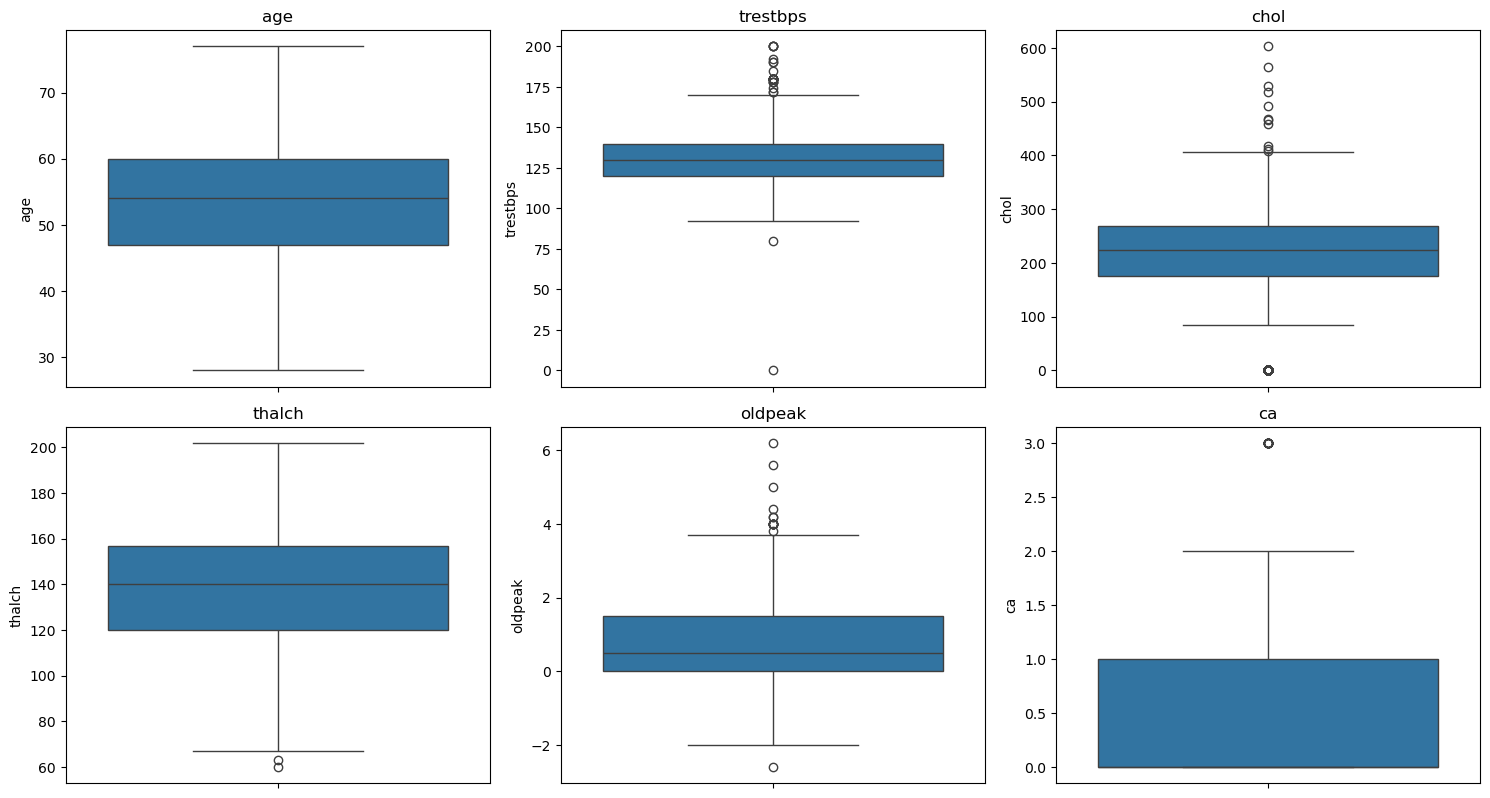

In [19]:
# Set figure size
plt.figure(figsize=(15, 12))

# Loop through all numerical columns and create subplots
for i, col in enumerate(num_features, 1):
    plt.subplot(len(num_features) // 3 + 1, 3, i)  # Adjust layout dynamically
    sns.boxplot(df[col])  # Histogram with density plot
    plt.title(col)

plt.tight_layout()
plt.show()

Here are some observations based on the box plots:
* trestbps (Resting Blood Pressure) and chol (Cholesterol) have some outliers above the upper whisker.
* oldpeak (ST Depression Induced by Exercise) also shows multiple high outliers.
* thalach (Maximum Heart Rate Achieved) has a few low outliers at the bottom.

Next steps:
* Consider outlier treatment (e.g., removal, or transformation).
* Explore potential feature engineering if outliers carry medical significance.

#### Age distribution across bins (multi-class classification)
**Purpose**: To observe how age groups are distributed across target classes.

What to Expect:
* Certain age groups might have higher occurrences of heart disease, indicating age is an important factor.
* Younger age groups (e.g., 20-39) might have fewer cases of heart disease compared to older age groups.

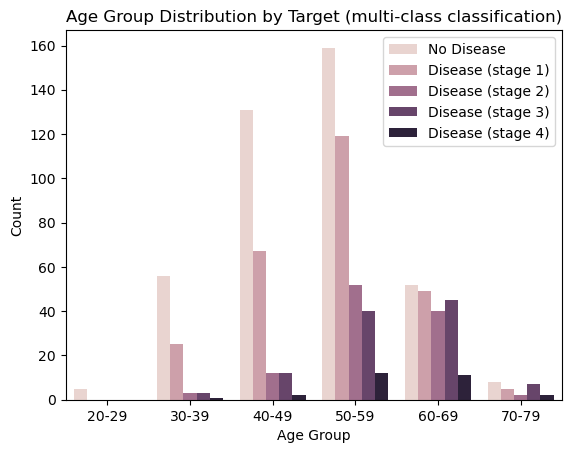

In [20]:
# Age distribution across bins (multi-class)
fig, ax = plt.subplots()
sns.countplot(x="age_bin", hue="num", data=df)
ax.set_title("Age Group Distribution by Target (multi-class classification)")
ax.set_xlabel("Age Group")
ax.set_ylabel("Count")
ax.legend(["No Disease", "Disease (stage 1)", "Disease (stage 2)", "Disease (stage 3)", "Disease (stage 4)"])
plt.show()

#### Age distribution across bins (binary classification)

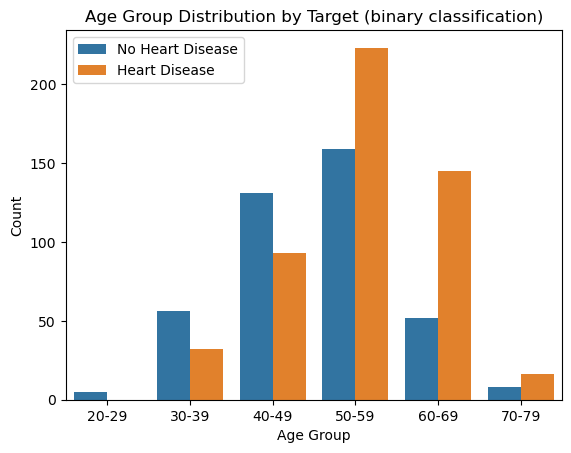

In [21]:
# Age distribution across bins (binary)
fig, ax = plt.subplots()
sns.countplot(x="age_bin", hue="num_bin", data=df)
ax.set_title("Age Group Distribution by Target (binary classification)")
ax.set_xlabel("Age Group")
ax.set_ylabel("Count")
ax.legend(["No Heart Disease", "Heart Disease"])
plt.show()

#### Age distribution across locations
**Purpose**: To observe how age groups are distributed across each location.

What to Expect:
* Certain age groups might have observed in specific locations

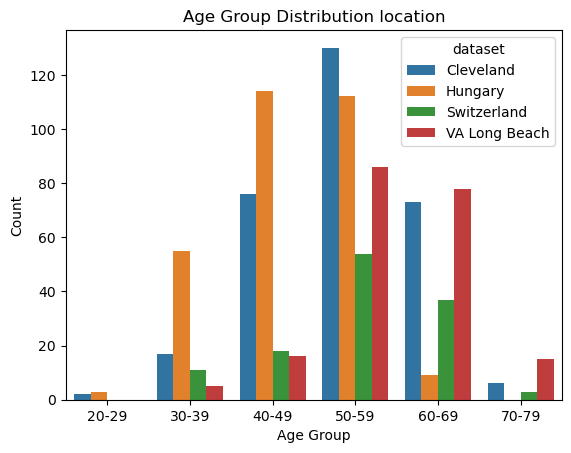

In [22]:
# Age distribution across locations
fig, ax = plt.subplots()
sns.countplot(x="age_bin", hue="dataset", data=df)
ax.set_title("Age Group Distribution location")
ax.set_xlabel("Age Group")
ax.set_ylabel("Count")
plt.show()

#### Aggregated Statistics by Sex and Target

**Purpose**: To summarize how age-related statistics (mean, median, count) vary across gender and target classes.

What to Expect:
* Males (sex = 1) might have a higher prevalence of heart disease.
* Analyze whether there are significant age differences within the groups.

In [23]:
# Grouping and aggregation 
grouped = df.groupby(['sex', 'num_bin'])['age'].agg(['mean', 'median', 'count']).reset_index()
print("Aggregated Statistics by Sex and Target:\n", grouped)

Aggregated Statistics by Sex and Target:
       sex  num_bin       mean  median  count
0  Female        0  51.187500    51.0    144
1  Female        1  56.180000    58.0     50
2    Male        0  50.202247    51.0    267
3    Male        1  55.873638    57.0    459


Some observations: 
1. people aged 50–59 have the highest prevalence of heart disease compared to younger or older groups.
2. Comparing the distribution of disease cases in younger (20–29) vs. older (60–69) groups might reveal risk factors linked to age.
3. A count plot of age_bin (grouped ages) vs. target will show cleaner bars with clearer insights into which age groups are at higher or lower risk.
4. Instead of focusing on whether 54-year-olds have higher cholesterol than 53-year-olds, binning can show how the 50–59 age group, in general, has higher cholesterol compared to the 40–49 group.
5. Analyzing the average cholesterol level or heart rate for each age group reveals whether older age groups tend to have higher values of these risk factors.
6. If the 50–59 age group shows the highest prevalence of heart disease, it might indicate that healthcare programs should prioritize screening and prevention for this demographic.

#### Violin Plot - Age vs Target
**Purpose**: To visualize the distribution of age for both target classes.

What to Expect:
* The age distribution might differ significantly between those with and without heart disease.
* Wider or denser sections indicate the age groups most common for heart disease.

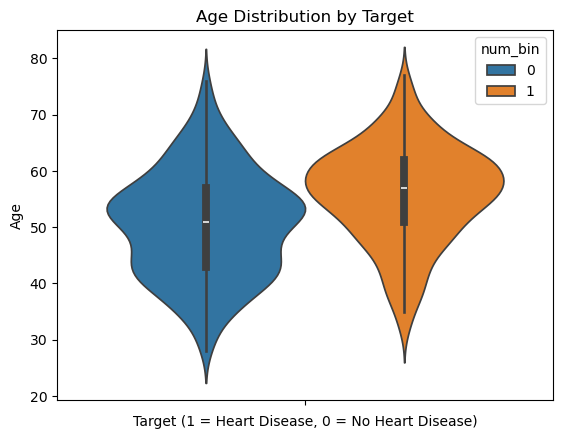

In [24]:
# Violin Plot - Age vs Target
fig, ax = plt.subplots()
sns.violinplot(hue="num_bin", y="age", data=df)
ax.set_title("Age Distribution by Target")
ax.set_xlabel("Target (1 = Heart Disease, 0 = No Heart Disease)")
ax.set_ylabel("Age")
plt.show()

#### Boxplot - Cholesterol Levels by Age Group and Target
**Purpose**: To analyze cholesterol levels across age groups for both target classes.

What to Expect:
* Higher cholesterol levels might correspond to a higher likelihood of heart disease.
* Age groups with significantly higher cholesterol levels for target = 1 should be noted.

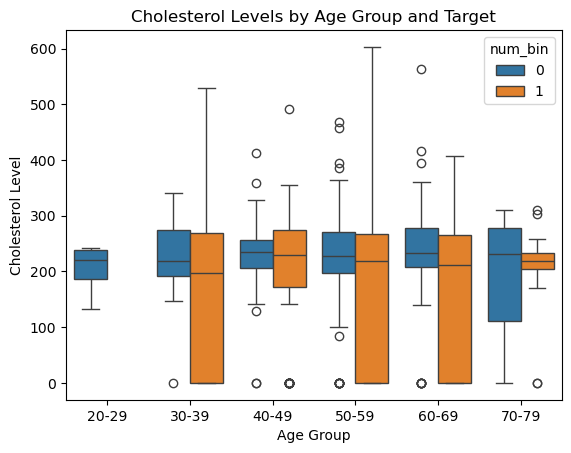

In [25]:
# Boxplot - Cholesterol levels across age bins
fig, ax = plt.subplots()
sns.boxplot(x="age_bin", y="chol", hue="num_bin", data=df)
ax.set_title("Cholesterol Levels by Age Group and Target")
ax.set_xlabel("Age Group")
ax.set_ylabel("Cholesterol Level")
plt.show()

#### Chest Pain Type Distribution by Target
**Purpose**: To analyze the relationship between chest pain type (cp) and heart disease.

What to Expect:
* Certain chest pain types (e.g., cp = asymptomatic or non-anginal) may be more indicative of heart disease.
* Less severe chest pain types might dominate in the no-disease class.

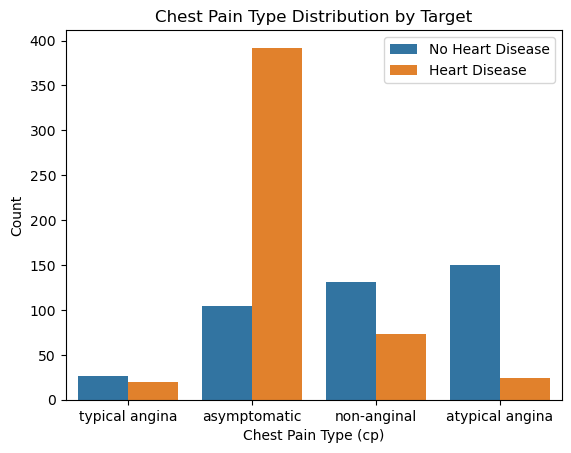

In [26]:
# Count plot - Distribution of Chest Pain Type (cp) by Target
fig, ax = plt.subplots()
sns.countplot(x="cp", hue="num_bin", data=df)
ax.set_title("Chest Pain Type Distribution by Target")
ax.set_xlabel("Chest Pain Type (cp)")
ax.set_ylabel("Count")
ax.legend(["No Heart Disease", "Heart Disease"])
plt.show()

#### Location Distribution by Target
**Purpose**: To analyze the relationship between location (dataset) and heart disease.

What to Expect:
* Certain locations may be prone to heart disease.

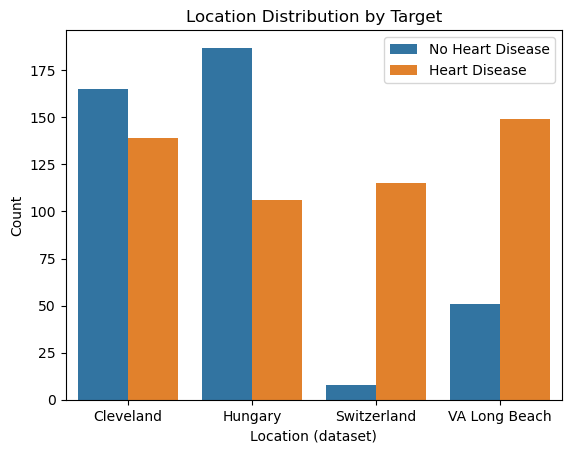

In [27]:
# Count plot - Distribution of location (dataset) by Target
fig, ax = plt.subplots()
sns.countplot(x="dataset", hue="num_bin", data=df)
ax.set_title("Location Distribution by Target")
ax.set_xlabel("Location (dataset)")
ax.set_ylabel("Count")
ax.legend(["No Heart Disease", "Heart Disease"])
plt.show()

#### Histogram - Resting Blood Pressure (trestbps)
**Purpose**: To visualize the distribution of resting blood pressure.

What to Expect:
* A higher resting blood pressure (trestbps) may correlate with heart disease.
* Look for any distinct clusters or outliers.

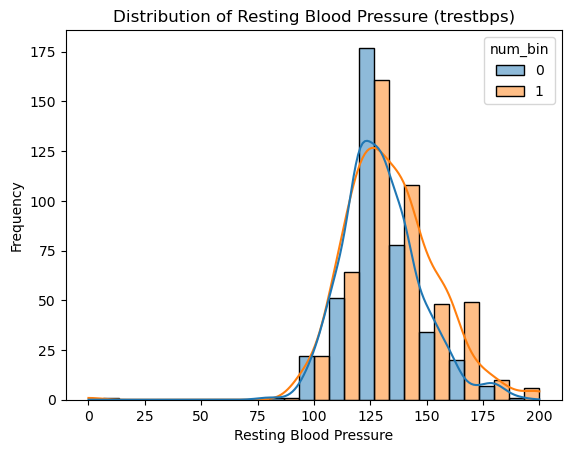

In [28]:
# Histogram for Resting Blood Pressure (trestbps) by Target
fig, ax = plt.subplots()
sns.histplot(data=df, x="trestbps", bins=15, kde=True, hue="num_bin", multiple="dodge")
ax.set_title("Distribution of Resting Blood Pressure (trestbps)")
ax.set_xlabel("Resting Blood Pressure")
ax.set_ylabel("Frequency")
plt.show()

#### Bar Plot - Mean Maximum Heart Rate (thalch) by Target
**Purpose**: To analyze the average maximum heart rate for both target classes.

What to Expect:
* Those with heart disease may have a lower average maximum heart rate (thalach), indicating reduced heart function.

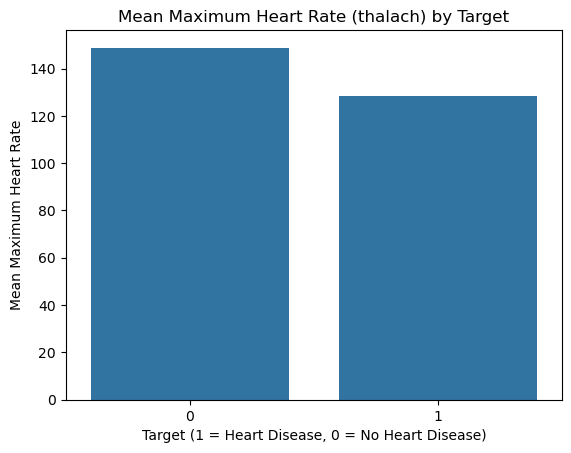

In [29]:
# Bar plot - Mean Maximum Heart Rate (thalch) by Target
fig, ax = plt.subplots()
thalch_mean = df.groupby("num_bin")["thalch"].mean().reset_index()
sns.barplot(x="num_bin", y="thalch", data=thalch_mean)
ax.set_title("Mean Maximum Heart Rate (thalach) by Target")
ax.set_xlabel("Target (1 = Heart Disease, 0 = No Heart Disease)")
ax.set_ylabel("Mean Maximum Heart Rate")
plt.show()

#### Pairplot of Numerical Features
**Purpose**: To visualize relationships between key numerical features and how they interact with the target variable.

What to Expect:
* Potential clustering of target = 1 and target = 0 cases in certain feature pairs (e.g., age vs thalch).
* Identify correlations or separations that can be used for prediction.

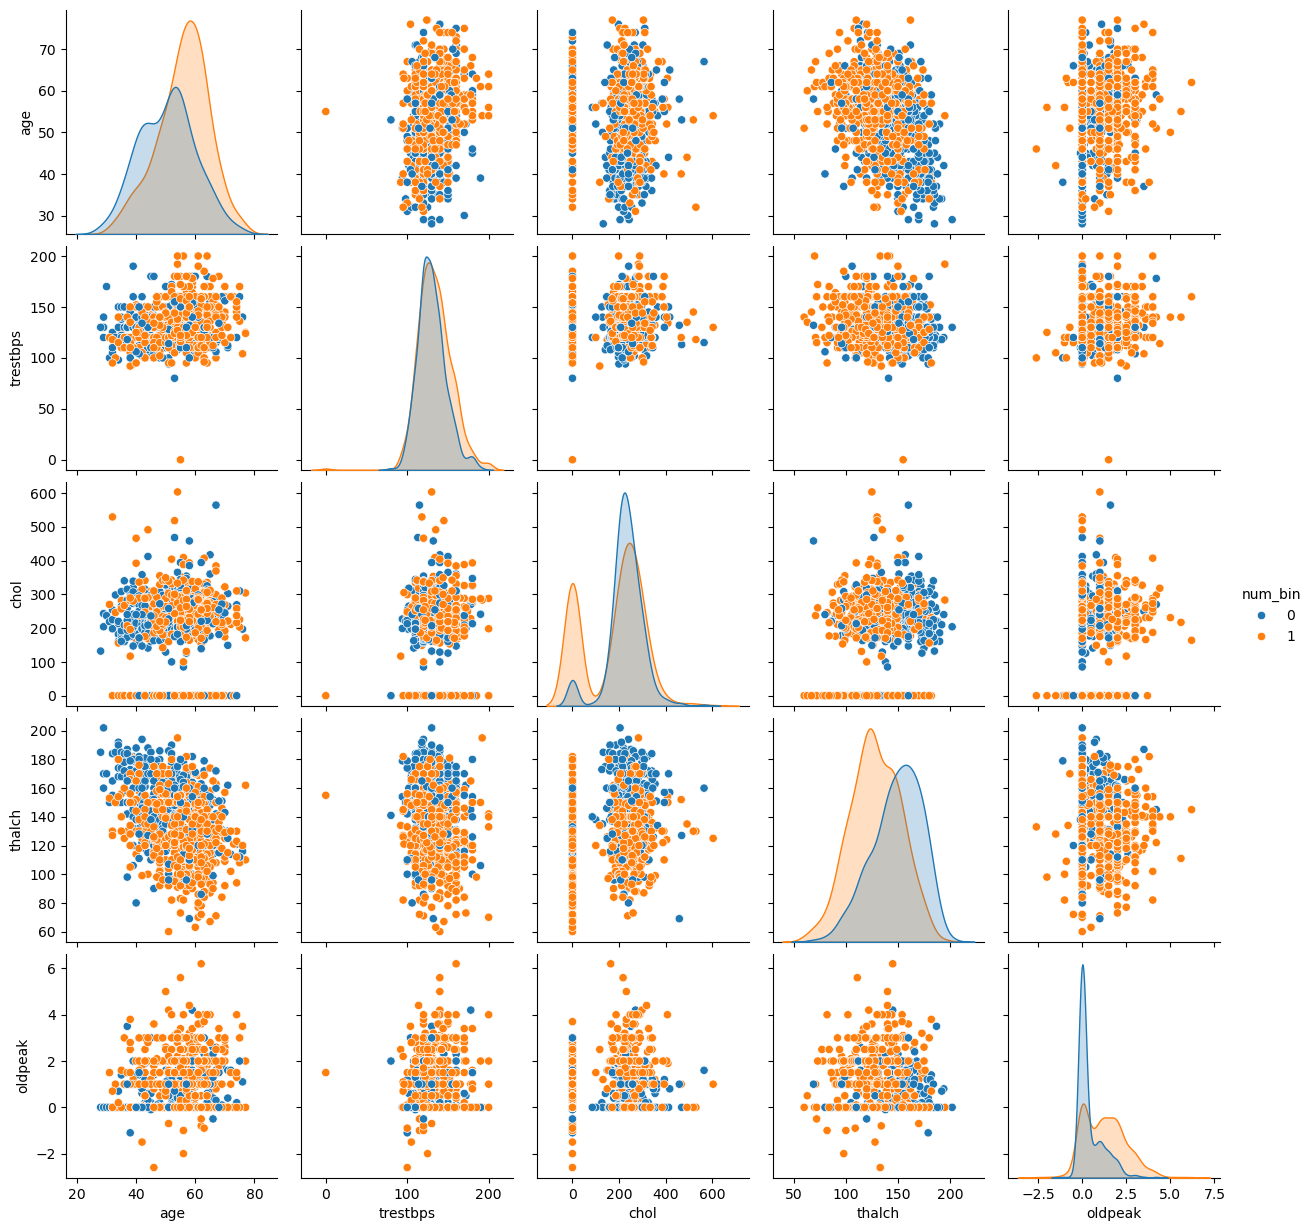

In [30]:
# Pairplot of numerical features
num_features = ["age", "trestbps", "chol", "thalch", "oldpeak"] # avoid ca from numerical features since it is merely a categorical (with distinct values) feature
sns.pairplot(df[num_features + ["num_bin"]], hue="num_bin")
plt.show()

#### Violin Plot for Oldpeak (ST Depression)
**Purpose**: To visualize the distribution of oldpeak values (exercise-induced ST depression).

What to Expect:
* Higher oldpeak values may be more associated with heart disease.
* Check if the distribution differs significantly between target classes.

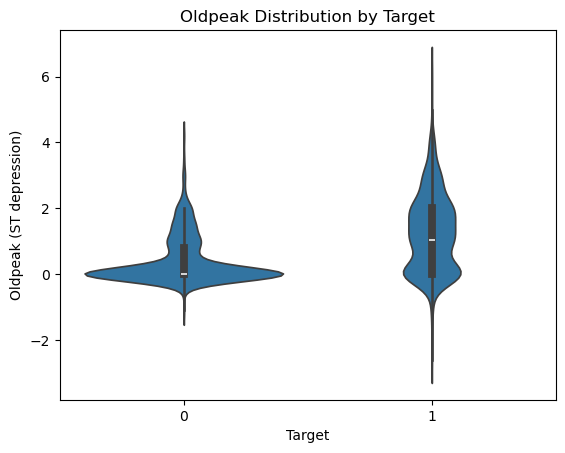

In [31]:
# Violin plot for oldpeak (ST depression)
fig, ax = plt.subplots()
sns.violinplot(x="num_bin", y="oldpeak", data=df)
ax.set_title("Oldpeak Distribution by Target")
ax.set_xlabel("Target")
ax.set_ylabel("Oldpeak (ST depression)")
plt.show()

#### Gender Distribution
**Purpose**: To examine the gender split in the dataset.

What to Expect:
* The dataset may be imbalanced by gender (e.g., more males than females).
* Males might show a higher prevalence of heart disease.

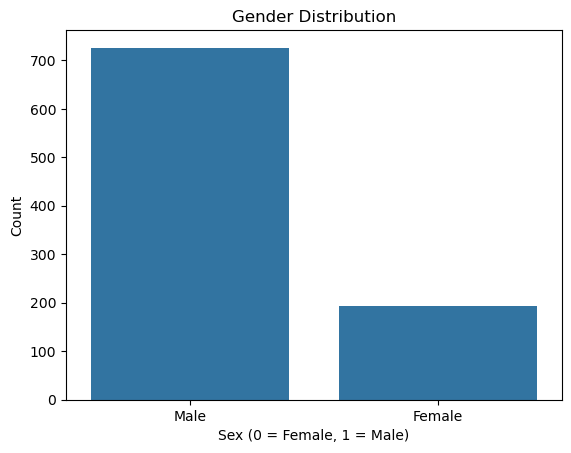

In [32]:
# Count plot - Gender Distribution
fig, ax = plt.subplots()
sns.countplot(x="sex", data=df)
ax.set_title("Gender Distribution")
ax.set_xlabel("Sex (0 = Female, 1 = Male)")
ax.set_ylabel("Count")
plt.show()

#### Average Cholesterol by Age Group
**Purpose**: To observe trends in cholesterol levels across age groups.

What to Expect:
* Older age groups may show higher average cholesterol levels.
* Compare trends between those with and without heart disease.

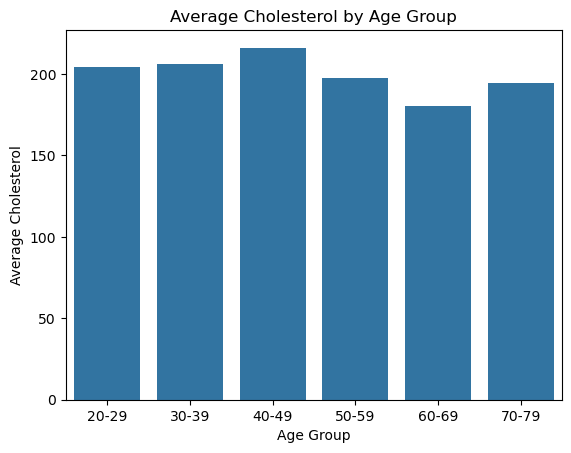

In [33]:
# Grouping - Average cholesterol by age group
chol_by_age = df.groupby("age_bin", observed=True)["chol"].mean().reset_index()
fig, ax = plt.subplots()
sns.barplot(x="age_bin", y="chol", data=chol_by_age)
ax.set_title("Average Cholesterol by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Average Cholesterol")
plt.show()

#### Exercise-Induced Angina Distribution by Target
**Purpose**: To analyze the relationship between exercise-induced angina (exang) and heart disease.

What to Expect:
* exang = 1 (presence of angina) may correlate strongly with heart disease.
* exang = 0 may dominate in the no-disease class.

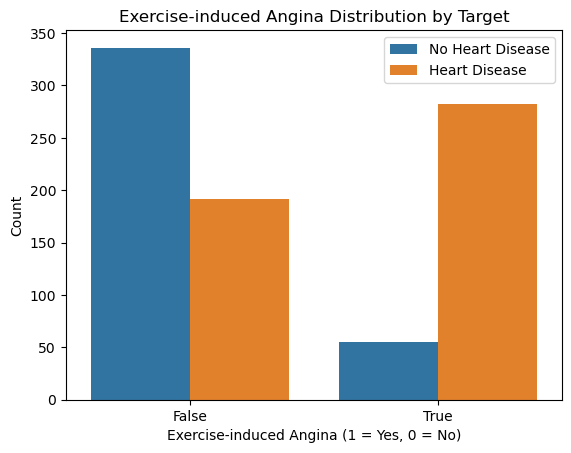

In [34]:
# Histogram - Target vs Exercise-induced angina (exang)
fig, ax = plt.subplots()
sns.countplot(x="exang", hue="num_bin", data=df)
ax.set_title("Exercise-induced Angina Distribution by Target")
ax.set_xlabel("Exercise-induced Angina (1 = Yes, 0 = No)")
ax.set_ylabel("Count")
ax.legend(["No Heart Disease", "Heart Disease"])
plt.show()

#### Density Plot of Maximum Heart Rate (thalach) by Target
**Purpose**: To observe the distribution of maximum heart rate for each target class.

What to Expect:
* A lower maximum heart rate (thalch) might be associated with heart disease.
* Differences in peaks and spread between the classes can indicate separation potential.

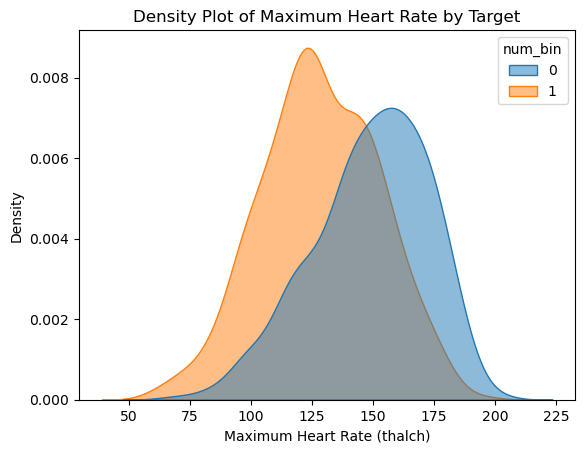

In [35]:
# Density plot for thalach (Maximum Heart Rate)
fig, ax = plt.subplots()
sns.kdeplot(data=df, x="thalch", hue="num_bin", fill=True, alpha=0.5)
ax.set_title("Density Plot of Maximum Heart Rate by Target")
ax.set_xlabel("Maximum Heart Rate (thalch)")
ax.set_ylabel("Density")
plt.show()